# JointPMF Data 

In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *


In [2]:
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt

subset = 'binary_data'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/pc_gsq/{subset}.pkl', 'rb') as f:
        results_pc_gsq = pickle.load(f)
    

    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_ea_hc = pickle.load(f)
        
    with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
        results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
        results_ea_fes = pickle.load(f)


    results_by_label = {
        "PC": results_pc,
        "PC-GSQ": results_pc_gsq,   
        "GES": results_ges,
        "HC": results_hc,
        "EA-HC": results_ea_hc,
        "EA-Base": results_ea_ues,
        "EA-IES": results_ea_ies,
        "EA-FES": results_ea_fes,
        "EA-FG": results_ea_fg,
        # "NOTEARS": results_notears,
        }



mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 12,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 12,            # axis-label size matches body text
    'xtick.labelsize'     : 12,             # tick labels one point smaller
    'ytick.labelsize'     : 12,
    'legend.fontsize'     : 12,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    # 'xtick.minor.size'    : 2,             # half of major — proportional
    # 'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    # 'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    # 'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 600,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})


In [3]:
## new plot code

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize


def pivot_grid(df, index, column, value_col, aggfunc="mean"):
    return df.pivot_table(index=index, columns=column, values=value_col, aggfunc=aggfunc)


def _iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)


def plot_heatmap_from_grid(
    grid,
    title,
    xlabel=None,
    ylabel=None,
    cbar_label=None,
    ax=None,
    vmin=None,
    vmax=None,
    cmap=None,
    norm=None,
    add_colorbar=True,
    annot_grid=None,
    fmt="{:.2f}",
    iqr_fmt="{:.2f}",
    text_size=8,
):
    """Matplotlib heatmap from a pivoted grid DataFrame, with optional shared scaling and cell annotations."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    data = grid.to_numpy(dtype=float)

    if norm is None:
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )
    else:
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            norm=norm,
            cmap=cmap,
        )

    if add_colorbar:
        cb = fig.colorbar(im, ax=ax)
        cb.set_label(cbar_label or "")

    x_pos = np.arange(len(grid.columns))
    y_pos = np.arange(len(grid.index))
    ax.set_xticks(x_pos)
    ax.set_yticks(y_pos)

    def _is_numeric_seq(seq):
        try:
            _ = np.asarray(seq, dtype=float)
            return True
        except Exception:
            return False

    cols = list(grid.columns)
    rows = list(grid.index)

    cols_numeric = _is_numeric_seq(cols)
    rows_numeric = _is_numeric_seq(rows)

    if cols_numeric:
        col_vals = np.asarray(cols, dtype=float)
        use_sci = (np.nanmax(np.abs(col_vals)) >= 1e5) or (
            np.nanmin(np.abs(col_vals[np.nonzero(col_vals)])) < 1e-2
            if np.any(col_vals != 0) else False
        )

        if use_sci:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:.0e}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
        else:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:g}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
    else:
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(cols[int(round(i))])
                if 0 <= int(round(i)) < len(cols) else ""
            )
        )

    if rows_numeric:
        row_vals = np.asarray(rows, dtype=float)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: f"{row_vals[int(round(i))]:g}"
                if 0 <= int(round(i)) < len(row_vals) else ""
            )
        )
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(rows[int(round(i))])
                if 0 <= int(round(i)) < len(rows) else ""
            )
        )

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_title(title)

    ax.tick_params(axis="x", labelrotation=45)
    ax.tick_params(axis="both", which="major", labelsize=9)

    # ---- annotations: mean and IQR ----
    if annot_grid is not None:
        annot_vals = annot_grid.to_numpy(dtype=float)

        finite_vals = data[np.isfinite(data)]
        midpoint = np.nanmean(finite_vals) if finite_vals.size else 0.0

        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                mean_val = data[r, c]
                iqr_val = annot_vals[r, c]

                if not np.isfinite(mean_val):
                    continue

                text = fmt.format(mean_val)
                if np.isfinite(iqr_val):
                    text += "\n[" + iqr_fmt.format(iqr_val) + "]"

                color = "white" if mean_val < midpoint else "black"
                ax.text(
                    c, r, text,
                    ha="center", va="center",
                    fontsize=text_size,
                    color=color,
                )

    return fig, ax, im


def _global_minmax(arrays, robust=False, q=(2, 98), symmetric=False):
    vals = []
    for a in arrays:
        if a is None:
            continue
        flat = np.asarray(a, dtype=float).ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size:
            vals.append(flat)
    if not vals:
        return None, None

    allv = np.concatenate(vals)

    if robust:
        lo, hi = np.nanpercentile(allv, [q[0], q[1]])
    else:
        lo, hi = np.nanmin(allv), np.nanmax(allv)

    if symmetric:
        m = np.nanmax(np.abs([lo, hi]))
        return -m, m
    return lo, hi


def plot_final_heatmap(
    long_df,
    plot_metric,
    x_col="samples",
    y_col="p_noise",
    x_label=None,
    y_label=None,
    ncols=None,
    filter=None,
    aggfunc="mean",
    figsize_per_col=(5, 4),
    sharey=True,
    standardize_colors=True,
    robust=False,
    robust_q=(2, 98),
    symmetric=False,
    fixed_vmin=None,
    fixed_vmax=None,
    cmap=None,
    single_colorbar=True,
    show_iqr=True,
    mean_fmt="{:.2f}",
    iqr_fmt="{:.2f}",
    text_size=8,
):
    """
    Plot heatmaps for an arbitrary number of algorithms/results, with standardized colors.
    Each cell can be annotated with mean and IQR.
    """
    labels = list(long_df["Algorithm"].unique())
    k = len(labels)

    if ncols is None:
        ncols = min(4, k)
    nrows = (k + ncols - 1) // ncols

    fig_w = figsize_per_col[0] * ncols
    fig_h = figsize_per_col[1] * nrows
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=True,
        sharey=sharey
    )

    axes_list = [axes] if k == 1 else list(np.ravel(axes))

    grids_by_label = {}
    iqr_grids_by_label = {}
    grid_arrays = []

    for label in labels:
        df = long_df[long_df["Algorithm"] == label]
        if filter is not None:
            filter_col, filter_val = filter
            df = df[df[filter_col] == filter_val]

        mean_grid = pivot_grid(df, index=y_col, column=x_col, value_col=plot_metric, aggfunc=aggfunc)
        grids_by_label[label] = mean_grid
        grid_arrays.append(mean_grid.to_numpy(dtype=float))

        if show_iqr:
            iqr_grid = pivot_grid(df, index=y_col, column=x_col, value_col=plot_metric, aggfunc=_iqr)
            iqr_grids_by_label[label] = iqr_grid
        else:
            iqr_grids_by_label[label] = None

    vmin = vmax = None
    norm = None
    if standardize_colors:
        if fixed_vmin is not None or fixed_vmax is not None:
            vmin = fixed_vmin
            vmax = fixed_vmax
        else:
            vmin, vmax = _global_minmax(
                grid_arrays,
                robust=robust,
                q=robust_q,
                symmetric=symmetric
            )
        norm = Normalize(vmin=vmin, vmax=vmax) if (vmin is not None and vmax is not None) else None

    last_im = None
    for i, label in enumerate(labels):
        ax = axes_list[i]
        grid = grids_by_label[label]
        iqr_grid = iqr_grids_by_label[label]

        _, _, im = plot_heatmap_from_grid(
            grid,
            title=f"{label} – {plot_metric}",
            cbar_label=plot_metric,
            ax=ax,
            cmap=cmap,
            norm=norm if standardize_colors else None,
            vmin=None if standardize_colors else fixed_vmin,
            vmax=None if standardize_colors else fixed_vmax,
            add_colorbar=(not single_colorbar) or (not standardize_colors),
            annot_grid=iqr_grid,
            fmt=mean_fmt,
            iqr_fmt=iqr_fmt,
            text_size=text_size,
        )
        ax.set_xlabel(x_col if x_label is None else x_label)
        ax.set_ylabel(y_col if y_label is None else y_label)
        last_im = im

    for j in range(k, len(axes_list)):
        axes_list[j].set_visible(False)

    if standardize_colors and single_colorbar and last_im is not None:
        cb = fig.colorbar(last_im, ax=[ax for ax in axes_list[:k]], shrink=0.9)
        cb.set_label(plot_metric)

    return fig, axes

## Check Jaccard Similarity for Found and Missing Colliders 

In [4]:
# stability analysis code 

from itertools import combinations
import numpy as np
import pandas as pd
from tqdm import tqdm

from metrics.graph import evaluate_colliders


def jaccard_similarity(set_a, set_b):
    """Compute Jaccard similarity between two sets."""
    union = set_a | set_b
    if not union:
        return 1.0  # both empty -> perfect agreement
    return len(set_a & set_b) / len(union)


def pairwise_jaccard_similarities(sets):
    """
    Compute Jaccard similarity for all distinct pairs in a list of sets.

    Parameters
    ----------
    sets : list[set]
        One set per run.

    Returns
    -------
    list[float]
        Pairwise Jaccard similarities.
    """
    return [
        jaccard_similarity(sets[i], sets[j])
        for i, j in combinations(range(len(sets)), 2)
    ]


def summarize_pairwise_jaccard(sets, prefix=None, ddof=1):
    """
    Compute summary statistics of pairwise Jaccard similarities.

    Parameters
    ----------
    sets : list[set]
        One set per run.
    prefix : str or None
        Optional prefix for returned dictionary keys.
    ddof : int
        Delta degrees of freedom for variance/std.
        Use ddof=1 for sample variance, ddof=0 for population variance.

    Returns
    -------
    dict
        Summary statistics for the pairwise Jaccard similarities.
    """
    sims = pairwise_jaccard_similarities(sets)

    if len(sims) == 0:
        stats = {
            "mean": np.nan,
            "var": np.nan,
            "std": np.nan,
            "min": np.nan,
            "q25": np.nan,
            "median": np.nan,
            "q75": np.nan,
            "iqr": np.nan,
            "max": np.nan,
            "n_pairs": 0,
        }
    else:
        sims = np.asarray(sims, dtype=float)
        q25 = np.quantile(sims, 0.25)
        q75 = np.quantile(sims, 0.75)

        # variance/std undefined for length 1 if ddof=1
        if len(sims) - ddof <= 0:
            var = np.nan
            std = np.nan
        else:
            var = float(np.var(sims, ddof=ddof))
            std = float(np.std(sims, ddof=ddof))

        stats = {
            "mean": float(np.mean(sims)),
            "var": var,
            "std": std,
            "min": float(np.min(sims)),
            "q25": float(q25),
            "median": float(np.median(sims)),
            "q75": float(q75),
            "iqr": float(q75 - q25),
            "max": float(np.max(sims)),
            "n_pairs": int(len(sims)),
        }

    if prefix is None:
        return stats

    return {f"{prefix}_{k}": v for k, v in stats.items()}


def stability_analysis(algo_results, ddof=1):
    """
    Compute stability summaries for each file/condition.

    Each row corresponds to one file/condition and contains summary statistics
    of pairwise Jaccard similarities across runs.

    Parameters
    ----------
    algo_results : list
        List of result objects, one per run/replication.
    ddof : int
        Delta degrees of freedom for variance/std.
        Use 1 for sample variance, 0 for population variance.

    Returns
    -------
    pd.DataFrame
        Stability summary dataframe.
    """
    rows = []

    file_ids = algo_results[0].learned_graphs.keys()

    for idx in tqdm(file_ids, desc="Processing graph indices"):
        all_learned_graphs = [res.learned_graphs[idx] for res in algo_results]

        # Edge sets
        all_learned_edges = [set(g.edges()) for g in all_learned_graphs]
        edge_stats = summarize_pairwise_jaccard(all_learned_edges, prefix="edges", ddof=ddof)

        # Collider-related sets
        graph_sets = [
            evaluate_colliders(
                algo_results[0].metadata_by_id[idx],
                g,
                algo_results[0].df_by_id[idx],
                return_sets=True,
            )
            for g in all_learned_graphs
        ]

        learned_collider_stats = summarize_pairwise_jaccard(
            [res["learned_colliders"] for res in graph_sets],
            prefix="learned_colliders",
            ddof=ddof,
        )

        correct_sc_stats = summarize_pairwise_jaccard(
            [res["correct_sc"] for res in graph_sets],
            prefix="correct_scs",
            ddof=ddof,
        )

        missing_sc_stats = summarize_pairwise_jaccard(
            [res["missing_sc"] for res in graph_sets],
            prefix="missing_scs",
            ddof=ddof,
        )

        extra_sc_stats = summarize_pairwise_jaccard(
            [res["extra_sc"] for res in graph_sets],
            prefix="extra_scs",
            ddof=ddof,
        )

        correct_pw_stats = summarize_pairwise_jaccard(
            [res["correct_pw"] for res in graph_sets],
            prefix="correct_pws",
            ddof=ddof,
        )

        missing_pw_stats = summarize_pairwise_jaccard(
            [res["missing_pw"] for res in graph_sets],
            prefix="missing_pws",
            ddof=ddof,
        )

        extra_pw_stats = summarize_pairwise_jaccard(
            [res["extra_pw"] for res in graph_sets],
            prefix="extra_pws",
            ddof=ddof,
        )

        row = {"file_id": idx}
        row.update(edge_stats)
        row.update(learned_collider_stats)
        row.update(correct_sc_stats)
        row.update(missing_sc_stats)
        row.update(extra_sc_stats)
        row.update(correct_pw_stats)
        row.update(missing_pw_stats)
        row.update(extra_pw_stats)

        # add condition metadata
        row.update(algo_results[0].df_by_id[idx].attrs)

        rows.append(row)

    stability_df = pd.DataFrame(rows).sort_values("file_id").reset_index(drop=True)
    return stability_df

### Save results to csv

In [5]:
import pandas as pd

binary_df = pd.read_csv("results/stability_analysis_binary_data.csv")
jpmf_df   = pd.read_csv("results/stability_analysis_jpmf_data.csv")

long_binary_df = pd.read_csv("results/long_df_binary_data.csv")
long_jpmf_df   = pd.read_csv("results/long_df_jpmf_data.csv")

stability_metrics = [
    "edges",
    "learned_colliders",
    "correct_scs", "missing_scs", "extra_scs",
    "correct_pws", "missing_pws", "extra_pws",
]

binary_group_cols = ["dag_family", "total_vars", "p_syn", "p_noise", "samples"]
jpmf_group_cols   = ["family", "num_vars", "target_mi", "pair_probs", "syn_cutoff"]

sub_jpmf_idx = long_jpmf_df[long_jpmf_df["Total (SC)"] > 0 & (long_jpmf_df["Total (PW)"] > 0)]["i"]
jpmf_df = jpmf_df[jpmf_df["i"].isin(sub_jpmf_idx)].copy()


### Figure 1 (Recovery stability across structural levels)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_recovery_stability_panel(df, metrics, dataset_label, ax=None):

    plot_df = df[list(metrics.keys())].rename(columns=metrics)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    data = [plot_df[col].dropna().values for col in plot_df.columns]
    positions = np.arange(1, len(data) + 1)

    # violin plots for distribution shape
    vp = ax.violinplot(
        data,
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    # optional styling
    for body in vp["bodies"]:
        body.set_alpha(0.35)

    # overlay boxplots for summary
    ax.boxplot(
        data,
        positions=positions,
        widths=0.25,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor="white", alpha=0.9),
        medianprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(plot_df.columns)
    ax.set_title(dataset_label)
    ax.set_ylabel("Mean pairwise Jaccard similarity")
    # ax.set_ylim(0, 1.02)

    return fig, ax


# def plot_figure1_recovery_stability(binary_df, jpmf_df, save_path=None):
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

#     plot_recovery_stability_panel(binary_df, "Binary", ax=axes[0])
#     # plot_recovery_stability_panel(jpmf_df, "JPMF", ax=axes[1])

#     fig.suptitle("Jaccard Similarity", y=1.02)
#     fig.tight_layout()

#     if save_path is not None:
#         fig.savefig(save_path, dpi=300, bbox_inches="tight")

#     return fig, axes

In [7]:
binary_df.head()

,file_id,edges_mean,edges_var,edges_std,edges_min,edges_q25,edges_median,edges_q75,edges_iqr,edges_max,...,extra_pws_q75,extra_pws_iqr,extra_pws_max,extra_pws_n_pairs,i,total_vars,dag_family,p_syn,p_noise,samples
0,0,0.661857,0.066808,0.258473,0.269231,0.437500,0.571429,1.000000,0.562500,1.0,...,1.0,1.0,1.0,45,0,10,ba,0.0,0.0,500
1,1,0.673437,0.051417,0.226754,0.318182,0.526316,0.571429,1.000000,0.473684,1.0,...,1.0,1.0,1.0,45,1,10,ba,0.0,0.0,1000
2,2,0.595395,0.030045,0.173336,0.350000,0.473684,0.571429,0.705882,0.232198,1.0,...,1.0,1.0,1.0,45,2,10,ba,0.0,0.0,2000
3,3,0.571958,0.026417,0.162532,0.291667,0.466667,0.562500,0.666667,0.200000,1.0,...,1.0,1.0,1.0,45,3,10,ba,0.0,0.0,5000
4,4,0.613251,0.033279,0.182425,0.333333,0.444444,0.571429,0.769231,0.324786,1.0,...,1.0,1.0,1.0,45,4,10,ba,0.0,0.0,10000


In [8]:
target_values = jpmf_df["target_mi"].unique()

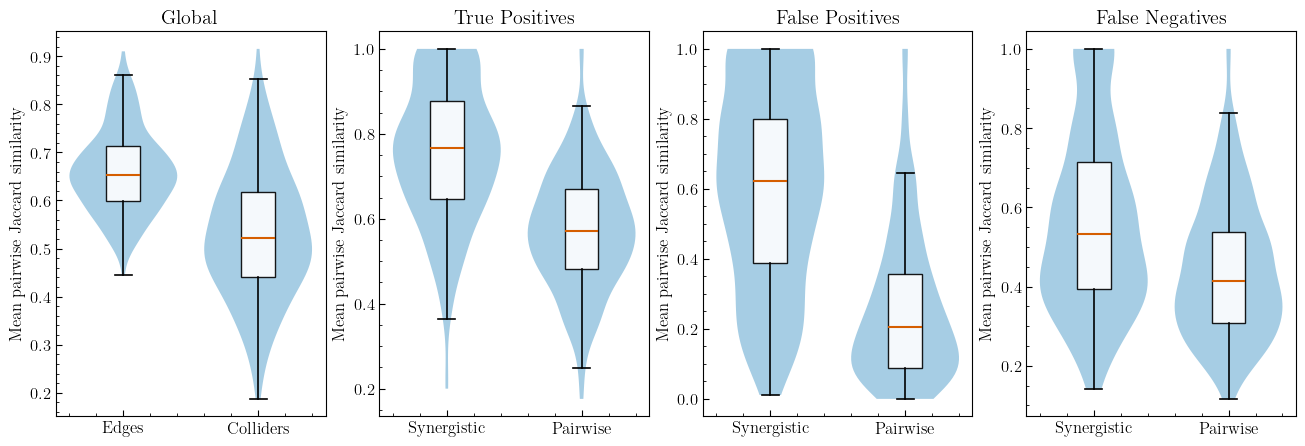

In [9]:
# orig_jpmf_df = jpmf_df.copy()

jpmf_df_30 = jpmf_df[(jpmf_df["num_vars"] == 30)].copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

i = 0
metrics = {
    # "edges_mean": "Edges",
    # "learned_colliders_mean": "Colliders",
    "edges_mean": "Edges",
    "learned_colliders_mean": "Colliders",

}
plot_recovery_stability_panel(jpmf_df_30, metrics, r"Global", ax=axes[i])
i += 1
metrics = {
    # "edges_mean": "Edges",
    # "learned_colliders_mean": "Colliders",
    "correct_scs_mean": "Synergistic",
    "correct_pws_mean": "Pairwise",

}

plot_recovery_stability_panel(jpmf_df_30, metrics, r"True Positives", ax=axes[i])
i += 1
metrics = {
    "extra_scs_mean": "Synergistic",
    "extra_pws_mean": "Pairwise",
}

plot_recovery_stability_panel(jpmf_df_30, metrics, r"False Positives", ax=axes[i])
i += 1
metrics = {"missing_scs_mean": "Synergistic",
    "missing_pws_mean": "Pairwise",
}

plot_recovery_stability_panel(jpmf_df_30, metrics, r"False Negatives", ax=axes[i])

metrics = {
    # "edges_mean": "Edges",
    # "learned_colliders_mean": "Colliders",
    "correct_scs_mean": "Synergistic",
    "correct_pws_mean": "Pairwise",

}




plt.savefig("Figures/recovery_stability_panels.png", dpi=300, bbox_inches="tight")


(<Figure size 400x500 with 1 Axes>,
 <Axes: title={'center': 'Global'}, ylabel='Mean pairwise Jaccard similarity'>)

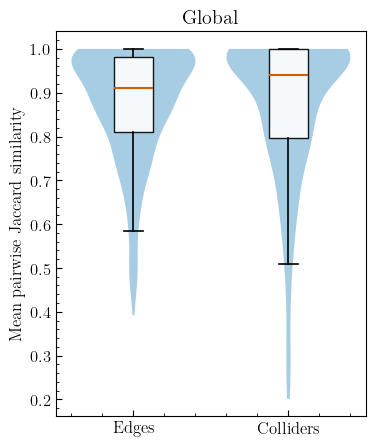

In [10]:
# orig_jpmf_df = jpmf_df.copy()
binary_df_30 = binary_df[(binary_df["total_vars"] == 30)].copy()

fig, axes = plt.subplots(1, 1, figsize=(4, 5), sharey=False)

i = 0
metrics = {
    # "edges_mean": "Edges",
    # "learned_colliders_mean": "Colliders",
    "edges_mean": "Edges",
    "learned_colliders_mean": "Colliders",

}
plot_recovery_stability_panel(binary_df_30, metrics, r"Global", ax=axes)



# plt.savefig("Figures/recovery_stability_panels.png", dpi=300, bbox_inches="tight")


In [14]:
load_results(subset)

algo_results = results_by_label["EA-FG"]


{'i': 300, 'total_vars': 20, 'dag_family': 'ba', 'p_syn': 0.5, 'p_noise': 0.0, 'samples': 500}


In [15]:
idx = 300
bic_score = algo_results[0].bic_scores[idx]
print(algo_results[0].df_by_id[idx].attrs)

{'i': 300, 'total_vars': 20, 'dag_family': 'ba', 'p_syn': 0.5, 'p_noise': 0.0, 'samples': 500}


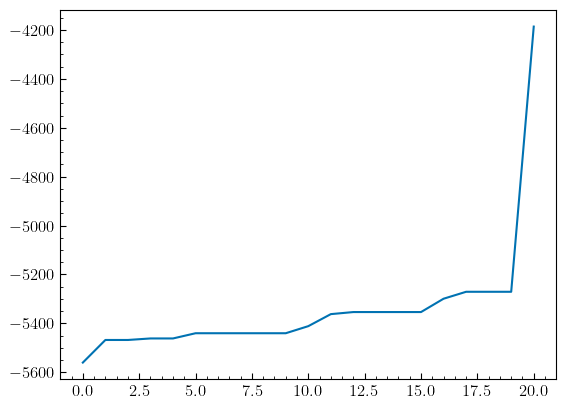

In [16]:
plt.plot(algo_results[0].bic_scores[300])